In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置 DataFrame 表格打印显示格式
pd.set_option('display.max_columns', None)  # 设置最大显示列数：None代表全部列都显示
pd.set_option('display.width', 2000)        # 设置输出表格宽度，数值调大，单位字符
pd.set_option('display.max_colwidth', 30)   # 每列最大字符长度

# 获取泰坦尼克号数据
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 打印一些基本信息看看
print(f"数据前 5 项预览：\n{df.head()}")
print(f"\n数据集形状：", df.shape)
print(f"\n数据类型与缺失值情况：")
print(df.info())

数据前 5 项预览：
   PassengerId  Survived  Pclass                           Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3        Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3         Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1  Futrelle, Mrs. Jacques Hea...  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3       Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S

数据集形状： (891, 12)

数据类型与缺失值情况：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  --

In [2]:
# 数值列统计描述
print("==== 数值特征统计描述 ====")
print(df.describe())

# 统计每列缺失值数量、缺失占比
print("\n==== 缺失值统计 ====")
missing = pd.DataFrame({
    "缺失数量": df.isnull().sum(),
    "缺失占比(%)": round(df.isnull().sum() / len(df) *100, 2)
})
print(missing)

==== 数值特征统计描述 ====
       PassengerId    Survived      Pclass         Age       SibSp       Parch        Fare
count   891.000000  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000    0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std     257.353842    0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min       1.000000    0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%     223.500000    0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%     446.000000    0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%     668.500000    1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max     891.000000    1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

==== 缺失值统计 ====
             缺失数量  缺失占比(%)
PassengerId     0     0.00
Survived        0     0.00
Pclass          0     0.00
Name            0     0.00
Sex       

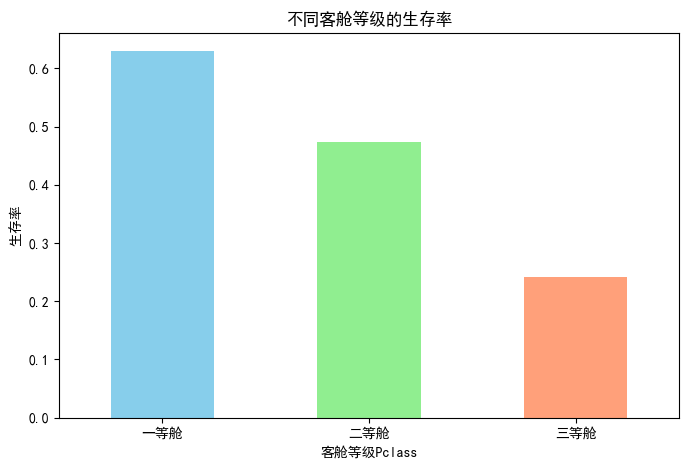

In [3]:
plt.figure(figsize=(8, 5))
# Pclass:客舱等级 1一等，2二等，3三等
survive_pclass = df.groupby("Pclass")["Survived"].mean()
survive_pclass.plot(kind="bar", color=["#87CEEB", "#90EE90", "#FFA07A"])
plt.title("不同客舱等级的生存率")
plt.ylabel("生存率")
plt.xlabel("客舱等级Pclass")
plt.xticks([0, 1, 2], ["一等舱", "二等舱", "三等舱"], rotation=0)
plt.show()

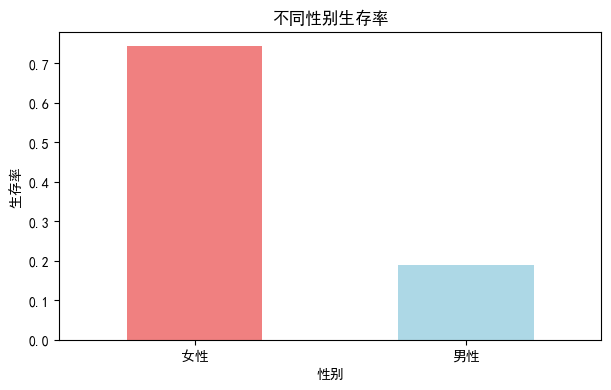

In [4]:
plt.figure(figsize=(7, 4))
survive_sex = df.groupby("Sex")["Survived"].mean()
survive_sex.plot(kind="bar", color=["lightcoral", "lightblue"])
plt.title("不同性别生存率")
plt.ylabel("生存率")
plt.xlabel("性别")
plt.xticks([0, 1], ["女性", "男性"], rotation=0)
plt.show()

In [5]:
# 1. 删除Cabin列，缺失太多无利用价值
df = df.drop("Cabin", axis=1)

# 2. Age用中位数填充
df["Age"] = df["Age"].fillna(df["Age"].median())

# 3. Embarked用众数填充
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# 4. 特征衍生：新增家庭大小特征 FamilySize = SibSp + Parch +1，把 SibSp 和 Parch 合并，重新跑模型，看指标是否提升（可合并也可不合并）
"""
合并之前：(逻辑回归, 随机森林) accuracy: (80.45%, 81.56%)
合并之后：(逻辑回归, 随机森林) accuracy: (80.45%, 81.01%)
"""
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 检查处理后是否还存在缺失
print("处理完缺失后的缺失统计：")
print(df.isnull().sum())

处理完缺失后的缺失统计：
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64


In [6]:
# 1 删除无用列
drop_cols = ["PassengerId", "Name", "Ticket"]
df = df.drop(columns=drop_cols)

# 2 One‑Hot独热编码，处理文本类别特征
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

print("处理完特征之后的列名：")
print(df.columns.tolist())
print("\n查看前3行数据: ")
print(df.head(3))

处理完特征之后的列名：
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Sex_male', 'Embarked_Q', 'Embarked_S']

查看前3行数据: 
   Survived  Pclass   Age  SibSp  Parch     Fare  FamilySize  Sex_male  Embarked_Q  Embarked_S
0         0       3  22.0      1      0   7.2500           2      True       False        True
1         1       1  38.0      1      0  71.2833           2     False       False       False
2         1       3  26.0      0      0   7.9250           1     False       False        True


In [7]:
from sklearn.model_selection import train_test_split

# X：全部特征，去掉目标列 Survived
X = df.drop("Survived", axis=1)
# y：预测标签，是否存活
y = df["Survived"]

# 划分训练集、测试集
# test_size=0.2: 测试集占20%
# stratify=y: 分层抽样，保证两集合存活比例一致
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"训练集大小 X_train:{X_train.shape}, y_train:{y_train.shape}")
print(f"测试集大小 X_test:{X_test.shape}, y_test:{y_test.shape}")

训练集大小 X_train:(712, 9), y_train:(712,)
测试集大小 X_test:(179, 9), y_test:(179,)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

print("========逻辑回归（标准化后）模型评估========")
print(f"测试集准确率 accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred))
print("\n分类报告：")
print(classification_report(y_test, y_pred))

========逻辑回归（标准化后）模型评估========
测试集准确率 accuracy: 80.45%

混淆矩阵：
[[98 12]
 [23 46]]

分类报告：
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("======== 随机森林模型评估 ========")
print(f"测试集准确率 accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred_rf))
print("\n分类报告：")
print(classification_report(y_test, y_pred_rf))

# 输出特征重要性
print("\n==== 特征重要性（数值越大对生存预测影响越大）====")
feature_importance = pd.DataFrame({
    "feature":X_train.columns,
    "importance":rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

======== 随机森林模型评估 ========
测试集准确率 accuracy: 81.01%

混淆矩阵：
[[95 15]
 [19 50]]

分类报告：
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


==== 特征重要性（数值越大对生存预测影响越大）====
      feature  importance
4        Fare    0.273412
6    Sex_male    0.261490
1         Age    0.237682
0      Pclass    0.085662
5  FamilySize    0.050495
2       SibSp    0.033592
3       Parch    0.024457
8  Embarked_S    0.024002
7  Embarked_Q    0.009208


In [10]:
# 获取测试集预测结果
test_result = X_test.copy()
test_result["真实_Survived"] = y_test
test_result["预测_Survived"] = y_pred_rf

# 输出csv文件，保存到你当前VSCode工作目录
test_result.to_csv("1.titanic_test_predict.csv", index=False, encoding="utf_8_sig")
print("1.预测文件已保存：titanic_test_predict.csv")

1.预测文件已保存：titanic_test_predict.csv


In [11]:
from sklearn.model_selection import GridSearchCV

# 1、设置要搜索的参数字典
param_grid = {
    "n_estimators": [50, 100, 150], # 森林中决策树棵数
    "max_depth": [3, 5, 7, 9, 11]   # 树最大深度，重点！
}

# 2、基础随机森林模型
rf = RandomForestClassifier(random_state=42)

# 3、网格搜索，5折交叉验证
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                # 5折交叉验证
    scoring="accuracy",  # 评估指标用准确率
    n_jobs=-1            # n_jobs=-1 使用电脑全部CPU，加速搜索
)

# ⚠️注意：fit只用训练集！绝对不能把X_test放进来！
grid_search.fit(X_train, y_train)

# 输出最优参数、最优交叉验证得分
print("✅网格搜索得到的最优参数：")
print(grid_search.best_params_)
print(f"\n训练集上5折交叉验证最优准确率：{grid_search.best_score_*100:.2f}%")

# 获取调参完毕的最优模型
best_rf = grid_search.best_estimator_

# 使用最优模型，在【从未见过的测试集】上评估！
y_pred_best = best_rf.predict(X_test)

print("\n======== 调参后最优模型，测试集评估 ========")
print(f"测试集准确率：{accuracy_score(y_test, y_pred_best)*100:.2f}%")
print(classification_report(y_test, y_pred_best))

feature_importance = pd.DataFrame({
    "feature":X_train.columns,
    "importance":best_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\n调参后特征重要性：")
print(feature_importance)

✅网格搜索得到的最优参数：
{'max_depth': 3, 'n_estimators': 100}

训练集上5折交叉验证最优准确率：82.17%

======== 调参后最优模型，测试集评估 ========
测试集准确率：79.89%
              precision    recall  f1-score   support

           0       0.78      0.94      0.85       110
           1       0.85      0.58      0.69        69

    accuracy                           0.80       179
   macro avg       0.82      0.76      0.77       179
weighted avg       0.81      0.80      0.79       179


调参后特征重要性：
      feature  importance
6    Sex_male    0.451692
4        Fare    0.177798
0      Pclass    0.161332
1         Age    0.074909
5  FamilySize    0.060430
2       SibSp    0.031093
8  Embarked_S    0.022414
3       Parch    0.012901
7  Embarked_Q    0.007431
